In [1]:
import chardet

with open("cleaned_seismic1.csv", 'rb') as f:
    result = chardet.detect(f.read(100000))
print(result)

{'encoding': 'ISO-8859-1', 'confidence': 0.73, 'language': ''}



================ Random Forest (Damage Index) ================
R² Score: -0.037
RMSE: 0.290
MAE: 0.250


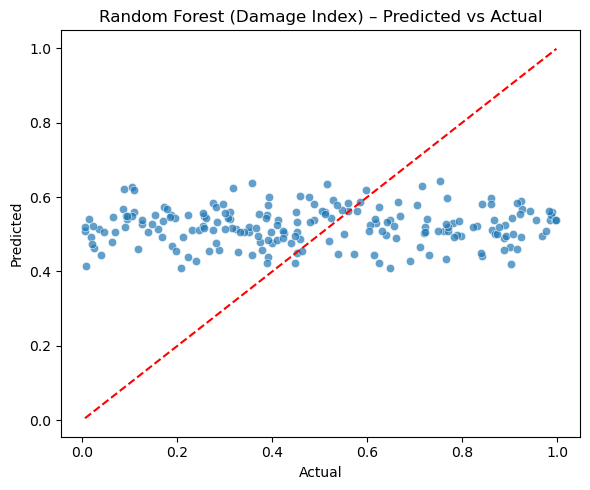


================ XGBoost (Damage Index) ================
R² Score: -0.082
RMSE: 0.297
MAE: 0.251


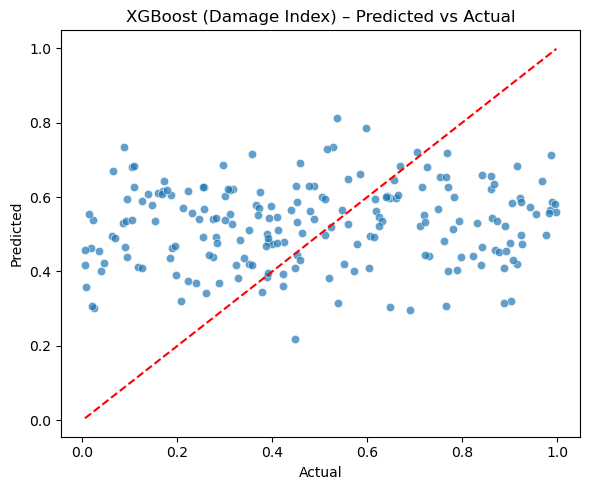


================ Random Forest (Collapse Probability) ================
R² Score: -0.029
RMSE: 28.906
MAE: 24.923


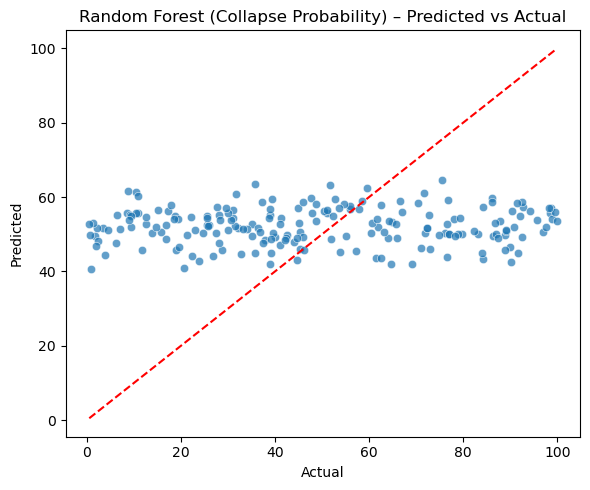


================ XGBoost (Collapse Probability) ================
R² Score: -0.078
RMSE: 29.592
MAE: 25.024


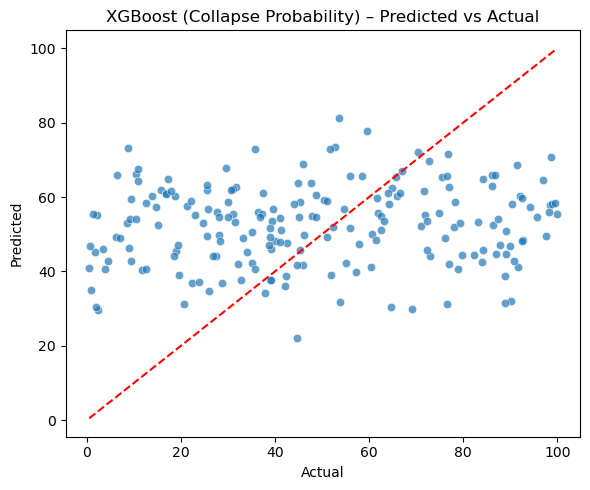

In [3]:
# === Sub-Problem A: Regression Models for Damage Index (Y2) and Collapse Probability (Y3) ===
# Author: Team AfterShock

# === 1. Import Libraries ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# === 2. Load Dataset ===
seismic_df = pd.read_csv("cleaned_seismic1.csv", encoding='ISO-8859-1')

# === 3. Define Features and Targets ===
X_B = seismic_df[[
    'Seismic Zone', 'PGA (m/s²)', 'PGV (m/s)', 'PGD (m)', 
    'Spectral Acceleration (g)', 'Soil Type', 'Site Amplification Factor', 
    'Historical Earthquake Magnitude (Mw)', 'Fault Distance (km)',
    'Seismic Wave Frequency (Hz)', 'Building Height (m)', 'Number of Stories', 
    'Structural Material', 'Foundation Type', 'Natural Frequency (Hz)', 
    'Damping Ratio (%)', 'Mass of Structure (kg)', 'Axial Stiffness (kN/m)', 
    'Bending Stiffness (kN·m²)', 'Lateral Load Resisting System'
]]

# Targets
y2 = seismic_df['Predicted Damage Index (01 Scale)']   # Y2
y3 = seismic_df['Predicted Collapse Probability (%)']  # Y3

# === 4. Encode Categorical Variables ===
X_encoded = pd.get_dummies(X_B, drop_first=True)

# === 5. Train-Test Split ===
X_train, X_test, y2_train, y2_test = train_test_split(X_encoded, y2, test_size=0.2, random_state=42)
_, _, y3_train, y3_test = train_test_split(X_encoded, y3, test_size=0.2, random_state=42)

# === 6. Feature Scaling (optional but helps for XGBoost consistency) ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === 7. Helper Function to Evaluate Regression Models ===
def evaluate_regression(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    
    print(f"\n================ {model_name} ================")
    print(f"R² Score: {r2:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"MAE: {mae:.3f}")
    
    # Plot predicted vs actual
    plt.figure(figsize=(6, 5))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"{model_name} – Predicted vs Actual")
    plt.tight_layout()
    plt.show()
    
    return model

# === 8. Train Models for Y2 ===
rf_y2 = RandomForestRegressor(n_estimators=300, random_state=42)
xgb_y2 = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)

rf_y2 = evaluate_regression(rf_y2, X_train, X_test, y2_train, y2_test, "Random Forest (Damage Index)")
xgb_y2 = evaluate_regression(xgb_y2, X_train_scaled, X_test_scaled, y2_train, y2_test, "XGBoost (Damage Index)")

# === 9. Train Models for Y3 ===
rf_y3 = RandomForestRegressor(n_estimators=300, random_state=42)
xgb_y3 = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42)

rf_y3 = evaluate_regression(rf_y3, X_train, X_test, y3_train, y3_test, "Random Forest (Collapse Probability)")
xgb_y3 = evaluate_regression(xgb_y3, X_train_scaled, X_test_scaled, y3_train, y3_test, "XGBoost (Collapse Probability)")


In [ ]:
# =============================================================
# === REGRESSION PIPELINE FOR DAMAGE INDEX (Y2) & COLLAPSE PROBABILITY (Y3) ===
# =============================================================

# === 1. Import Libraries ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings('ignore')

# === 2. Load Dataset ===
seismic_df = pd.read_csv("cleaned_seismic1.csv", encoding='ISO-8859-1')

# === 3. Define Features and Targets ===
X = seismic_df[[
    'Seismic Zone', 'PGA (m/s²)', 'PGV (m/s)', 'PGD (m)',
    'Spectral Acceleration (g)', 'Soil Type', 'Site Amplification Factor',
    'Historical Earthquake Magnitude (Mw)', 'Fault Distance (km)',
    'Seismic Wave Frequency (Hz)', 'Building Height (m)', 'Number of Stories',
    'Structural Material', 'Foundation Type', 'Natural Frequency (Hz)',
    'Damping Ratio (%)', 'Mass of Structure (kg)', 'Axial Stiffness (kN/m)',
    'Bending Stiffness (kN·m²)', 'Lateral Load Resisting System'
]]

# --- Targets ---
y2 = seismic_df['Predicted Damage Index (01 Scale)']   # Y2
y3 = seismic_df['Predicted Collapse Probability (%)']  # Y3

# === 4. Encode Categorical Features ===
X_encoded = pd.get_dummies(X, drop_first=True)

# === 5. Split into Train/Test ===
X_train, X_test, y2_train, y2_test = train_test_split(X_encoded, y2, test_size=0.2, random_state=42)
_, _, y3_train, y3_test = train_test_split(X_encoded, y3, test_size=0.2, random_state=42)

# === 6. Scale Features ===
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# === 7. Evaluation Helper ===
def evaluate_regression(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)

    # 10-Fold Cross Validation
    cv = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2')

    return {
        "Model": model_name,
        "R²": round(r2, 3),
        "RMSE": round(rmse, 3),
        "MAE": round(mae, 3),
        "CV Mean R²": round(cv_scores.mean(), 3)
    }

# === 8. Define Models ===
models = [
    (LinearRegression(), "Linear Regression"),
    (Ridge(alpha=1.0), "Ridge Regression"),
    (Lasso(alpha=0.001), "Lasso Regression"),
    (SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1), "SVR (RBF Kernel)"),
    (KNeighborsRegressor(n_neighbors=8), "KNN Regressor"),
    (RandomForestRegressor(n_estimators=300, random_state=42), "Random Forest"),
    (XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=5, random_state=42), "XGBoost")
]

# === 9. Evaluate All Models (Y2 & Y3) ===
results_y2 = []
results_y3 = []

for model, name in models:
    res2 = evaluate_regression(model, X_train_scaled, X_test_scaled, y2_train, y2_test, name + " (Y2)")
    res3 = evaluate_regression(model, X_train_scaled, X_test_scaled, y3_train, y3_test, name + " (Y3)")
    results_y2.append(res2)
    results_y3.append(res3)

# === 10. Results Comparison Tables ===
df_y2 = pd.DataFrame(results_y2)
df_y3 = pd.DataFrame(results_y3)

print("\n================ Damage Index (Y2) Models Comparison ================")
print(df_y2.sort_values("R²", ascending=False))

print("\n================ Collapse Probability (Y3) Models Comparison ================")
print(df_y3.sort_values("R²", ascending=False))

# =============================================================
# === 11. Hyperparameter Tuning for Random Forest & XGBoost ===
# =============================================================

print("\n\n=== Grid Search: Random Forest (Y2) ===")
rf_param_grid = {
    'n_estimators': [200, 500, 800],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
rf_grid = GridSearchCV(RandomForestRegressor(random_state=42),
                       rf_param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
rf_grid.fit(X_train_scaled, y2_train)
print("Best RF Params:", rf_grid.best_params_)
print("Best RF CV R²:", round(rf_grid.best_score_, 3))

print("\n=== Grid Search: XGBoost (Y2) ===")
xgb_param_grid = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
}
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=42),
    xgb_param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1
)
xgb_grid.fit(X_train_scaled, y2_train)
print("Best XGB Params:", xgb_grid.best_params_)
print("Best XGB CV R²:", round(xgb_grid.best_score_, 3))



================ Damage Index (Y2) Models Comparison ================
                    Model     R²   RMSE    MAE  CV Mean R²
2   Lasso Regression (Y2) -0.026  0.289  0.248      -0.056
0  Linear Regression (Y2) -0.029  0.289  0.249      -0.063
1   Ridge Regression (Y2) -0.029  0.289  0.249      -0.063
5      Random Forest (Y2) -0.038  0.290  0.250      -0.068
6            XGBoost (Y2) -0.070  0.295  0.252      -0.171
3   SVR (RBF Kernel) (Y2) -0.147  0.305  0.261      -0.101
4      KNN Regressor (Y2) -0.195  0.312  0.272      -0.149

================ Collapse Probability (Y3) Models Comparison ================
                    Model     R²    RMSE     MAE  CV Mean R²
5      Random Forest (Y3) -0.028  28.900  24.918      -0.072
0  Linear Regression (Y3) -0.029  28.916  24.877      -0.063
1   Ridge Regression (Y3) -0.029  28.915  24.877      -0.063
2   Lasso Regression (Y3) -0.029  28.915  24.877      -0.063
6            XGBoost (Y3) -0.070  29.482  25.184      -0.171
4      KNN R